In [10]:
import os
import pandas as pd

base_path = "/Users/vihangainduwara/Desktop/MelanoDetect copy/data/ham10000"
metadata_path = os.path.join(base_path, "HAM10000_metadata.csv")
images_part1 = os.path.join(base_path, "HAM10000_images_part_1")
images_part2 = os.path.join(base_path, "HAM10000_images_part_2")

print("Metadata exists:", os.path.exists(metadata_path))
print("Part 1 exists:", os.path.exists(images_part1))
print("Part 2 exists:", os.path.exists(images_part2))

Metadata exists: True
Part 1 exists: True
Part 2 exists: True


In [11]:
df = pd.read_csv(metadata_path)
print(df.shape)
df.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [12]:
print(df.columns.tolist())

['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


In [13]:
print(df["dx"].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [14]:
import glob

image_paths_part1 = glob.glob(os.path.join(images_part1, "*.jpg"))
image_paths_part2 = glob.glob(os.path.join(images_part2, "*.jpg"))

all_image_paths = image_paths_part1 + image_paths_part2

print("Images in part 1:", len(image_paths_part1))
print("Images in part 2:", len(image_paths_part2))
print("Total images found:", len(all_image_paths))

Images in part 1: 5000
Images in part 2: 5015
Total images found: 10015


In [15]:
image_path_dict = {
    os.path.splitext(os.path.basename(path))[0]: path
    for path in all_image_paths
}

print("Mapped image IDs:", len(image_path_dict))

Mapped image IDs: 10015


In [16]:
df["image_path"] = df["image_id"].map(image_path_dict)

print("Missing image paths:", df["image_path"].isna().sum())
df[["image_id", "dx", "image_path"]].head()

Missing image paths: 0


,image_id,dx,image_path
0,ISIC_0027419,bkl,/Users/vihangainduwara/Desktop/MelanoDetect co...
1,ISIC_0025030,bkl,/Users/vihangainduwara/Desktop/MelanoDetect co...
2,ISIC_0026769,bkl,/Users/vihangainduwara/Desktop/MelanoDetect co...
3,ISIC_0025661,bkl,/Users/vihangainduwara/Desktop/MelanoDetect co...
4,ISIC_0031633,bkl,/Users/vihangainduwara/Desktop/MelanoDetect co...


In [17]:
label_map = {
    "akiec": "Actinic keratoses",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

df["dx_full"] = df["dx"].map(label_map)

df[["image_id", "dx", "dx_full"]].head()

,image_id,dx,dx_full
0,ISIC_0027419,bkl,Benign keratosis-like lesions
1,ISIC_0025030,bkl,Benign keratosis-like lesions
2,ISIC_0026769,bkl,Benign keratosis-like lesions
3,ISIC_0025661,bkl,Benign keratosis-like lesions
4,ISIC_0031633,bkl,Benign keratosis-like lesions


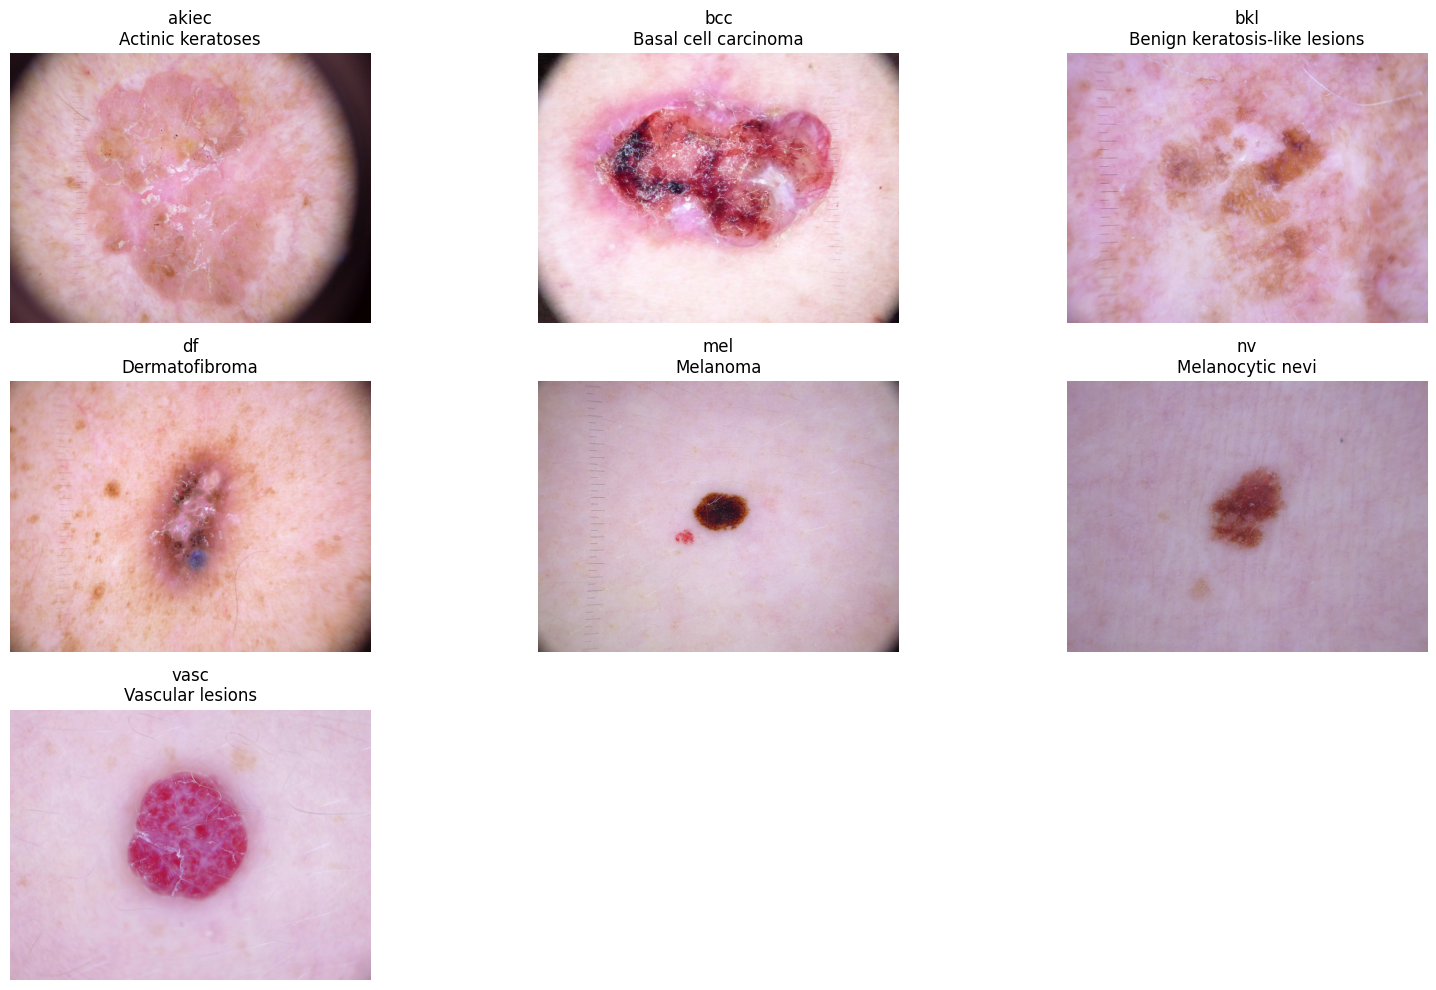

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df.groupby("dx").first().reset_index()

plt.figure(figsize=(16, 10))

for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.image_path)
    
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(f"{row.dx}\n{row.dx_full}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
print(df["dx"].unique())
print("Number of classes:", df["dx"].nunique())

['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']
Number of classes: 7


In [20]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["dx"],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Temp shape:", temp_df.shape)

Train shape: (7010, 9)
Temp shape: (3005, 9)


In [21]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=42
)

print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Validation shape: (1502, 9)
Test shape: (1503, 9)


In [22]:
print("Train class distribution:")
print(train_df["dx"].value_counts())

print("\nValidation class distribution:")
print(val_df["dx"].value_counts())

print("\nTest class distribution:")
print(test_df["dx"].value_counts())

Train class distribution:
dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

Validation class distribution:
dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       21
df         17
Name: count, dtype: int64

Test class distribution:
dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       22
df         17
Name: count, dtype: int64


In [23]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(train_df.head())

     lesion_id      image_id   dx    dx_type   age     sex localization  \
0  HAM_0000946  ISIC_0031775   nv  follow_up  60.0    male        trunk   
1  HAM_0006097  ISIC_0027306  mel      histo  60.0    male        chest   
2  HAM_0004348  ISIC_0033895   nv  consensus  40.0  female      unknown   
3  HAM_0006608  ISIC_0025491   nv      histo  60.0    male         back   
4  HAM_0005678  ISIC_0031023  mel      histo  60.0    male        chest   

                                          image_path           dx_full  
0  /Users/vihangainduwara/Desktop/MelanoDetect co...  Melanocytic nevi  
1  /Users/vihangainduwara/Desktop/MelanoDetect co...          Melanoma  
2  /Users/vihangainduwara/Desktop/MelanoDetect co...  Melanocytic nevi  
3  /Users/vihangainduwara/Desktop/MelanoDetect co...  Melanocytic nevi  
4  /Users/vihangainduwara/Desktop/MelanoDetect co...          Melanoma  


In [24]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [25]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [26]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [18]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [19]:
print(train_generator.class_indices)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [20]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 7)


In [21]:
from tensorflow.keras import layers, models

In [22]:
cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(7, activation='softmax')
])

In [23]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,527 (50.49 MB)

 Trainable params: 13,235,527 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
import os

model_save_dir = "/Users/vihangainduwara/Desktop/MelanoDetect copy/models"
os.makedirs(model_save_dir, exist_ok=True)

checkpoint_path = os.path.join(model_save_dir, "ham10000_cnn.keras")
print("Model will be saved to:", checkpoint_path)

Model will be saved to: /Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_cnn.keras


In [26]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array(list(train_generator.class_indices.keys()))
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["dx"]
)

class_weight_dict = {
    train_generator.class_indices[class_name]: weight
    for class_name, weight in zip(classes, class_weights_array)
}

print(class_weight_dict)

{0: np.float64(4.37305053025577), 1: np.float64(2.7817460317460316), 2: np.float64(1.3022478172023035), 3: np.float64(12.36331569664903), 4: np.float64(1.285530900421786), 5: np.float64(0.21338772031292808), 6: np.float64(10.115440115440116)}


In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [28]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.1489 - loss: 2.0723
Epoch 1: val_loss improved from None to 1.88625, saving model to /Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_cnn.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 120s 543ms/step - accuracy: 0.1706 - loss: 1.9817 - val_accuracy: 0.3688 - val_loss: 1.8862 - learning_rate: 0.0010
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.1092 - loss: 1.9890
Epoch 2: val_loss did not improve from 1.88625
220/220 ━━━━━━━━━━━━━━━━━━━━ 131s 597ms/step - accuracy: 0.0417 - loss: 1.9475 - val_accuracy: 0.0113 - val_loss: 1.9629 - learning_rate: 0.0010
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.0411 - loss: 1.9568
Epoch 3: val_loss did not improve from 1.88625

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
220/220 ━━━━━━━━━━━━━━━━━━━━ 116s 528ms/step - accuracy: 0.0525 - loss: 1.9471 - val_accuracy: 0.0419 - val_loss: 1.9538 - learning_rat

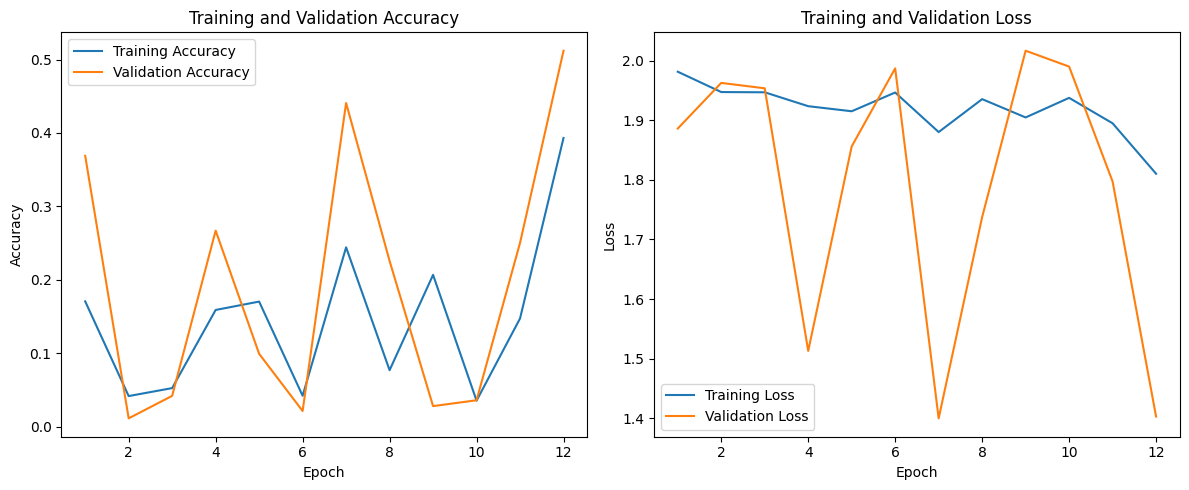

In [29]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
from tensorflow.keras.models import load_model

best_model = load_model(checkpoint_path)
print("Best model loaded successfully")

Best model loaded successfully


In [31]:
test_loss, test_acc = best_model.evaluate(test_generator)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - accuracy: 0.4458 - loss: 1.4261
Test Loss: 1.4260658025741577
Test Accuracy: 0.4457751214504242


In [32]:
import numpy as np

test_generator.reset()
pred_probs = best_model.predict(test_generator, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step


              precision    recall  f1-score   support

       akiec       0.08      0.02      0.03        49
         bcc       0.17      0.01      0.02        77
         bkl       0.29      0.05      0.08       165
          df       0.03      0.82      0.05        17
         mel       0.23      0.16      0.19       167
          nv       0.86      0.61      0.72      1006
        vasc       0.04      0.14      0.07        22

    accuracy                           0.45      1503
   macro avg       0.24      0.26      0.17      1503
weighted avg       0.65      0.45      0.51      1503



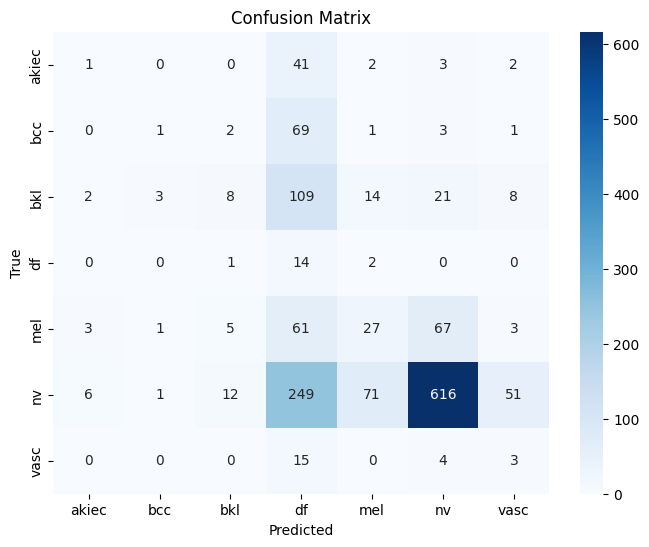

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(classification_report(true_classes, pred_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [34]:
binary_map = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "malignant",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign"
}

df["binary_label"] = df["dx"].map(binary_map)

In [35]:
print(df["binary_label"].value_counts())
df[["image_id", "dx", "binary_label"]].head(10)

binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


,image_id,dx,binary_label
0,ISIC_0027419,bkl,benign
1,ISIC_0025030,bkl,benign
2,ISIC_0026769,bkl,benign
3,ISIC_0025661,bkl,benign
4,ISIC_0031633,bkl,benign
5,ISIC_0027850,bkl,benign
6,ISIC_0029176,bkl,benign
7,ISIC_0029068,bkl,benign
8,ISIC_0025837,bkl,benign
9,ISIC_0025209,bkl,benign


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
binary_train_df, binary_temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["binary_label"],
    random_state=42
)

print("Binary train shape:", binary_train_df.shape)
print("Binary temp shape:", binary_temp_df.shape)

Binary train shape: (7010, 10)
Binary temp shape: (3005, 10)


In [38]:
binary_val_df, binary_test_df = train_test_split(
    binary_temp_df,
    test_size=0.50,
    stratify=binary_temp_df["binary_label"],
    random_state=42
)

print("Binary validation shape:", binary_val_df.shape)
print("Binary test shape:", binary_test_df.shape)

Binary validation shape: (1502, 10)
Binary test shape: (1503, 10)


In [39]:
print("Binary train distribution:")
print(binary_train_df["binary_label"].value_counts())

print("\nBinary validation distribution:")
print(binary_val_df["binary_label"].value_counts())

print("\nBinary test distribution:")
print(binary_test_df["binary_label"].value_counts())

Binary train distribution:
binary_label
benign       5642
malignant    1368
Name: count, dtype: int64

Binary validation distribution:
binary_label
benign       1209
malignant     293
Name: count, dtype: int64

Binary test distribution:
binary_label
benign       1210
malignant     293
Name: count, dtype: int64


In [40]:
binary_train_df = binary_train_df.reset_index(drop=True)
binary_val_df = binary_val_df.reset_index(drop=True)
binary_test_df = binary_test_df.reset_index(drop=True)

In [41]:
BINARY_IMG_SIZE = (224, 224)
BINARY_BATCH_SIZE = 16

In [42]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

binary_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

binary_val_test_datagen = ImageDataGenerator(rescale=1./255)

In [43]:
binary_train_generator = binary_train_datagen.flow_from_dataframe(
    dataframe=binary_train_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=BINARY_IMG_SIZE,
    batch_size=BINARY_BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

Found 7010 validated image filenames belonging to 2 classes.


In [44]:
binary_val_generator = binary_val_test_datagen.flow_from_dataframe(
    dataframe=binary_val_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=BINARY_IMG_SIZE,
    batch_size=BINARY_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1502 validated image filenames belonging to 2 classes.


In [45]:
binary_test_generator = binary_val_test_datagen.flow_from_dataframe(
    dataframe=binary_test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=BINARY_IMG_SIZE,
    batch_size=BINARY_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1503 validated image filenames belonging to 2 classes.


In [46]:
print(binary_train_generator.class_indices)

{'benign': 0, 'malignant': 1}


In [47]:
binary_images, binary_labels = next(binary_train_generator)

print("Binary image batch shape:", binary_images.shape)
print("Binary label batch shape:", binary_labels.shape)

Binary image batch shape: (16, 224, 224, 3)
Binary label batch shape: (16,)


In [48]:
from tensorflow.keras import layers, models

In [49]:
binary_cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [50]:
binary_cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [51]:
binary_cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,233,985 (50.48 MB)

 Trainable params: 13,233,985 (50.48 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
import os

binary_model_save_dir = "/Users/vihangainduwara/Desktop/MelanoDetect copy/models"
os.makedirs(binary_model_save_dir, exist_ok=True)

binary_checkpoint_path = os.path.join(binary_model_save_dir, "ham10000_binary_cnn.keras")
print("Binary model will be saved to:", binary_checkpoint_path)

Binary model will be saved to: /Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn.keras


In [53]:
import os

binary_model_save_dir = "/Users/vihangainduwara/Desktop/MelanoDetect copy/models"
os.makedirs(binary_model_save_dir, exist_ok=True)

binary_checkpoint_path = os.path.join(binary_model_save_dir, "ham10000_binary_cnn.keras")
print("Binary model will be saved to:", binary_checkpoint_path)

Binary model will be saved to: /Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn.keras


In [54]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

binary_classes = np.array([0, 1])  # benign=0, malignant=1

binary_class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=binary_classes,
    y=binary_train_generator.classes
)

binary_class_weight_dict = {
    0: binary_class_weights_array[0],
    1: binary_class_weights_array[1]
}

print(binary_class_weight_dict)

{0: np.float64(0.6212336051045728), 1: np.float64(2.5621345029239766)}


In [55]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

binary_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=binary_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [56]:
binary_history = binary_cnn_model.fit(
    binary_train_generator,
    validation_data=binary_val_generator,
    epochs=15,
    class_weight=binary_class_weight_dict,
    callbacks=binary_callbacks
)

Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.5094 - loss: 0.7148
Epoch 1: val_loss improved from None to 0.69408, saving model to /Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 131s 297ms/step - accuracy: 0.5534 - loss: 0.6943 - val_accuracy: 0.2264 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.4447 - loss: 0.6992
Epoch 2: val_loss did not improve from 0.69408
439/439 ━━━━━━━━━━━━━━━━━━━━ 129s 293ms/step - accuracy: 0.3849 - loss: 0.6958 - val_accuracy: 0.1951 - val_loss: 0.7079 - learning_rate: 0.0010
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.2940 - loss: 0.6880
Epoch 3: val_loss did not improve from 0.69408

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
439/439 ━━━━━━━━━━━━━━━━━━━━ 126s 287ms/step - accuracy: 0.3188 - loss: 0.6933 - val_accuracy: 0.1951 - val_loss: 0.6992 - learn

In [57]:
from tensorflow.keras import layers, models

binary_cnn_model_v2 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [58]:
binary_cnn_model_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [59]:
binary_checkpoint_path_v2 = "/Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras"
print(binary_checkpoint_path_v2)

/Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras


In [60]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

binary_callbacks_v2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=binary_checkpoint_path_v2,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [61]:
binary_history_v2 = binary_cnn_model_v2.fit(
    binary_train_generator,
    validation_data=binary_val_generator,
    epochs=15,
    callbacks=binary_callbacks_v2
)

Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.7965 - loss: 0.5264
Epoch 1: val_loss improved from None to 0.44777, saving model to /Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 135s 306ms/step - accuracy: 0.8041 - loss: 0.4798 - val_accuracy: 0.8049 - val_loss: 0.4478 - learning_rate: 0.0010
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.8114 - loss: 0.4460
Epoch 2: val_loss did not improve from 0.44777
439/439 ━━━━━━━━━━━━━━━━━━━━ 128s 291ms/step - accuracy: 0.8049 - loss: 0.4503 - val_accuracy: 0.8049 - val_loss: 0.4511 - learning_rate: 0.0010
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.8074 - loss: 0.4472
Epoch 3: val_loss did not improve from 0.44777

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
439/439 ━━━━━━━━━━━━━━━━━━━━ 128s 291ms/step - accuracy: 0.8049 - loss: 0.4595 - val_accuracy: 0.8049 - val_loss: 0.4692 - le

In [62]:
from tensorflow.keras.models import load_model

best_binary_model = load_model(binary_checkpoint_path_v2)
print("Best binary model loaded successfully")

Best binary model loaded successfully


In [63]:
binary_test_loss, binary_test_acc = best_binary_model.evaluate(binary_test_generator)
print("Binary Test Loss:", binary_test_loss)
print("Binary Test Accuracy:", binary_test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.8144 - loss: 0.3485
Binary Test Loss: 0.34849250316619873
Binary Test Accuracy: 0.8143712282180786


In [64]:
import numpy as np

binary_test_generator.reset()
binary_pred_probs = best_binary_model.predict(binary_test_generator, verbose=1).flatten()
binary_pred_labels = (binary_pred_probs > 0.5).astype(int)

binary_true_labels = binary_test_generator.classes

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step


In [65]:
from sklearn.metrics import classification_report

print(classification_report(
    binary_true_labels,
    binary_pred_labels,
    target_names=["benign", "malignant"]
))

              precision    recall  f1-score   support

      benign       0.85      0.93      0.89      1210
   malignant       0.54      0.34      0.42       293

    accuracy                           0.81      1503
   macro avg       0.70      0.64      0.65      1503
weighted avg       0.79      0.81      0.80      1503



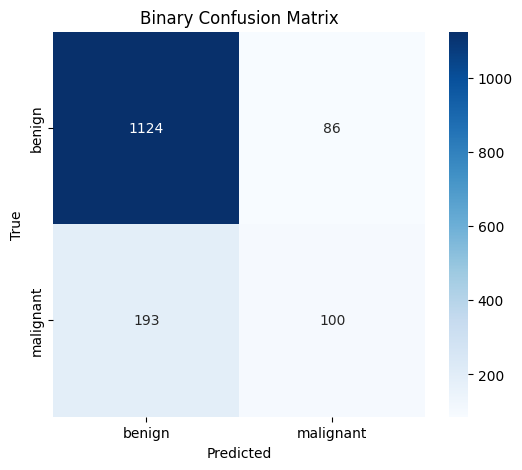

In [66]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

binary_cm = confusion_matrix(binary_true_labels, binary_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    binary_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["benign", "malignant"],
    yticklabels=["benign", "malignant"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Binary Confusion Matrix")
plt.show()

In [1]:
from tensorflow.keras.models import load_model

best_binary_model = load_model("/Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras")
print("Best binary model loaded successfully")

Best binary model loaded successfully


In [2]:
print(binary_test_generator.samples)
print(binary_test_generator.class_indices)

NameError: name 'binary_test_generator' is not defined

In [3]:
print("df exists:", "df" in globals())
print("binary_test_df exists:", "binary_test_df" in globals())

df exists: False
binary_test_df exists: False


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BINARY_IMG_SIZE = (224, 224)
BINARY_BATCH_SIZE = 16

binary_val_test_datagen = ImageDataGenerator(rescale=1./255)

binary_test_generator = binary_val_test_datagen.flow_from_dataframe(
    dataframe=binary_test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=BINARY_IMG_SIZE,
    batch_size=BINARY_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

NameError: name 'binary_test_df' is not defined

In [6]:
import os
import glob
import pandas as pd

base_path = "/Users/vihangainduwara/Desktop/MelanoDetect copy/data/ham10000"
metadata_path = os.path.join(base_path, "HAM10000_metadata.csv")
images_part1 = os.path.join(base_path, "HAM10000_images_part_1")
images_part2 = os.path.join(base_path, "HAM10000_images_part_2")

df = pd.read_csv(metadata_path)

image_paths_part1 = glob.glob(os.path.join(images_part1, "*.jpg"))
image_paths_part2 = glob.glob(os.path.join(images_part2, "*.jpg"))
all_image_paths = image_paths_part1 + image_paths_part2

image_path_dict = {
    os.path.splitext(os.path.basename(path))[0]: path
    for path in all_image_paths
}

df["image_path"] = df["image_id"].map(image_path_dict)

print(df.shape)
print(df.head())

(10015, 8)
     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

                                          image_path  
0  /Users/vihangainduwara/Desktop/MelanoDetect co...  
1  /Users/vihangainduwara/Desktop/MelanoDetect co...  
2  /Users/vihangainduwara/Desktop/MelanoDetect co...  
3  /Users/vihangainduwara/Desktop/MelanoDetect co...  
4  /Users/vihangainduwara/Desktop/MelanoDetect co...  


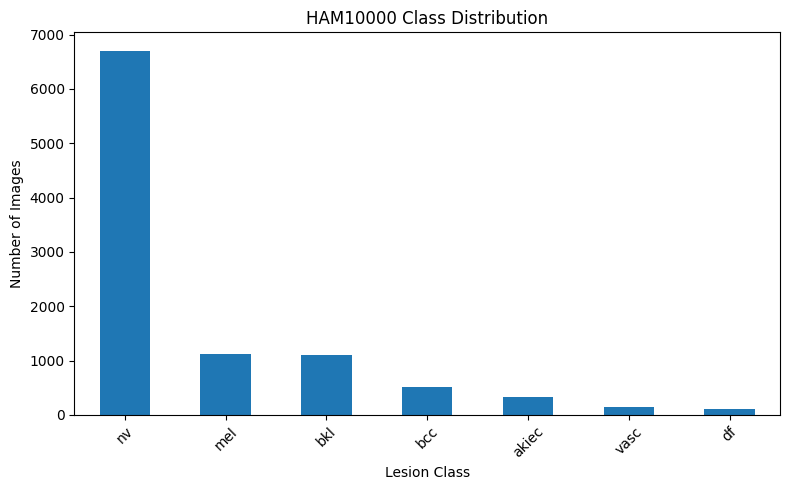

In [7]:
import matplotlib.pyplot as plt

class_counts = df["dx"].value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("HAM10000 Class Distribution")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
import matplotlib.pyplot as plt

acc = binary_history_v2.history["accuracy"]
val_acc = binary_history_v2.history["val_accuracy"]
loss = binary_history_v2.history["loss"]
val_loss = binary_history_v2.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'binary_history_v2' is not defined

In [28]:
binary_history_v2 = binary_cnn_model_v2.fit(...)

NameError: name 'binary_cnn_model_v2' is not defined

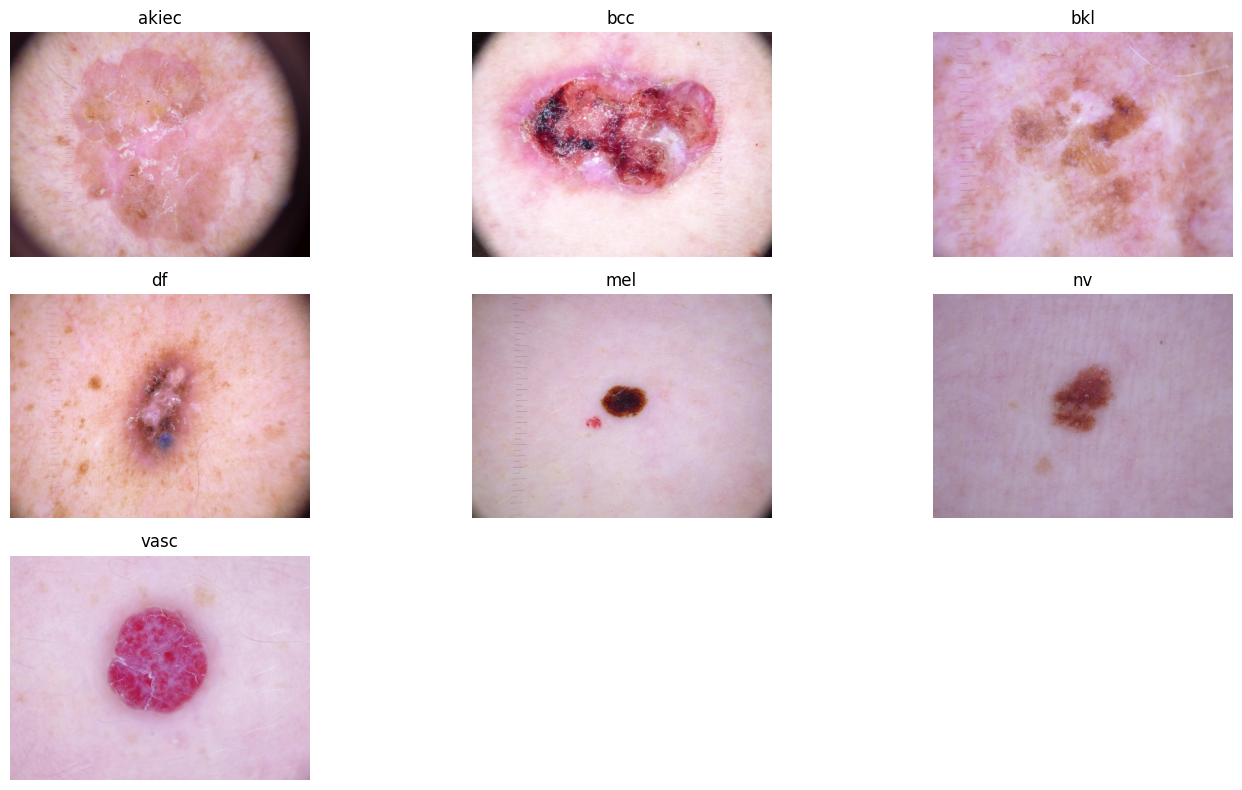

In [29]:
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df.groupby("dx").first().reset_index()

plt.figure(figsize=(14,8))

for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.image_path)
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(f"{row.dx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
from tensorflow.keras import layers, models

binary_cnn_model_v2 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [31]:
binary_cnn_model_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [32]:
binary_checkpoint_path_v2 = "/Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras"

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

binary_callbacks_v2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=binary_checkpoint_path_v2,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [34]:
binary_history_v2 = binary_cnn_model_v2.fit(
    binary_train_generator,
    validation_data=binary_val_generator,
    epochs=15,
    callbacks=binary_callbacks_v2
)

NameError: name 'binary_train_generator' is not defined

In [35]:
import os
import glob
import pandas as pd

base_path = "/Users/vihangainduwara/Desktop/MelanoDetect copy/data/ham10000"
metadata_path = os.path.join(base_path, "HAM10000_metadata.csv")
images_part1 = os.path.join(base_path, "HAM10000_images_part_1")
images_part2 = os.path.join(base_path, "HAM10000_images_part_2")

df = pd.read_csv(metadata_path)

image_paths_part1 = glob.glob(os.path.join(images_part1, "*.jpg"))
image_paths_part2 = glob.glob(os.path.join(images_part2, "*.jpg"))
all_image_paths = image_paths_part1 + image_paths_part2

image_path_dict = {
    os.path.splitext(os.path.basename(path))[0]: path
    for path in all_image_paths
}

df["image_path"] = df["image_id"].map(image_path_dict)

print(df.shape)
print("Missing image paths:", df["image_path"].isna().sum())

(10015, 8)
Missing image paths: 0


In [36]:
binary_map = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "malignant",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign"
}

df["binary_label"] = df["dx"].map(binary_map)
print(df["binary_label"].value_counts())

binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


In [37]:
from sklearn.model_selection import train_test_split

binary_train_df, binary_temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["binary_label"],
    random_state=42
)

binary_val_df, binary_test_df = train_test_split(
    binary_temp_df,
    test_size=0.50,
    stratify=binary_temp_df["binary_label"],
    random_state=42
)

binary_train_df = binary_train_df.reset_index(drop=True)
binary_val_df = binary_val_df.reset_index(drop=True)
binary_test_df = binary_test_df.reset_index(drop=True)

print(binary_train_df.shape)
print(binary_val_df.shape)
print(binary_test_df.shape)

(7010, 9)
(1502, 9)
(1503, 9)


In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BINARY_IMG_SIZE = (224, 224)
BINARY_BATCH_SIZE = 16

binary_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

binary_val_test_datagen = ImageDataGenerator(rescale=1./255)

binary_train_generator = binary_train_datagen.flow_from_dataframe(
    dataframe=binary_train_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=BINARY_IMG_SIZE,
    batch_size=BINARY_BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

binary_val_generator = binary_val_test_datagen.flow_from_dataframe(
    dataframe=binary_val_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=BINARY_IMG_SIZE,
    batch_size=BINARY_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

binary_test_generator = binary_val_test_datagen.flow_from_dataframe(
    dataframe=binary_test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=BINARY_IMG_SIZE,
    batch_size=BINARY_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print(binary_train_generator.class_indices)

Found 7010 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
{'benign': 0, 'malignant': 1}


In [39]:
binary_history_v2 = binary_cnn_model_v2.fit(
    binary_train_generator,
    validation_data=binary_val_generator,
    epochs=15,
    callbacks=binary_callbacks_v2
)

Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.8059 - loss: 0.4971
Epoch 1: val_loss improved from None to 0.44975, saving model to /Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 127s 288ms/step - accuracy: 0.8041 - loss: 0.4774 - val_accuracy: 0.8049 - val_loss: 0.4497 - learning_rate: 0.0010
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8130 - loss: 0.4400
Epoch 2: val_loss improved from 0.44975 to 0.44029, saving model to /Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 124s 282ms/step - accuracy: 0.8049 - loss: 0.4499 - val_accuracy: 0.8049 - val_loss: 0.4403 - learning_rate: 0.0010
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.8082 - loss: 0.4405
Epoch 3: val_loss did not improve from 0.44029
439/439 ━━━━━━━━━━━━━━━━━━━━ 122s 277ms/step - accuracy: 0.8049 - loss: 0.4400 - val_accuracy: 0

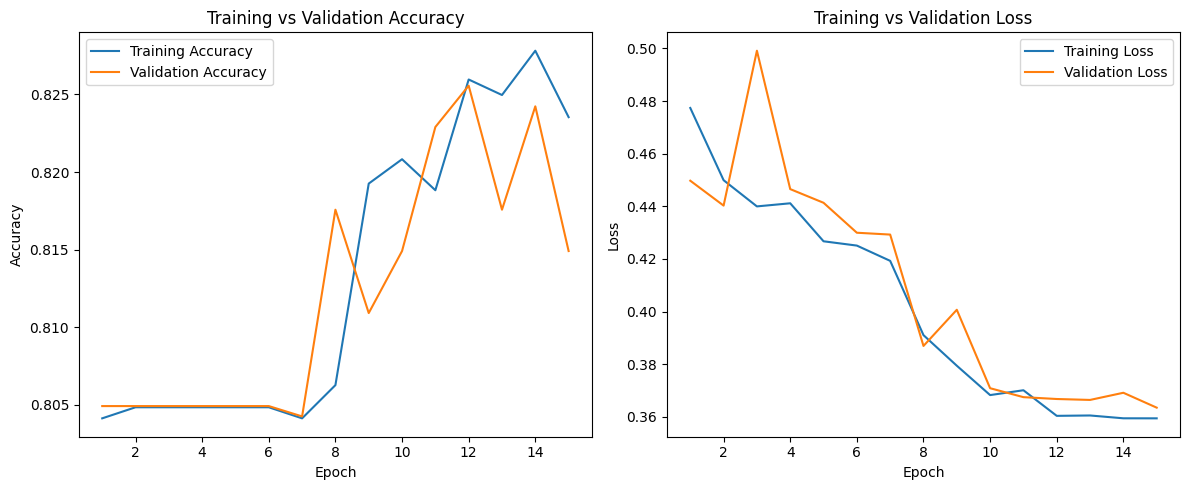

In [40]:
import matplotlib.pyplot as plt

acc = binary_history_v2.history["accuracy"]
val_acc = binary_history_v2.history["val_accuracy"]
loss = binary_history_v2.history["loss"]
val_loss = binary_history_v2.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [47]:
from tensorflow.keras.models import load_model

binary_checkpoint_path_v2 = "/Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras"
best_binary_model = load_model(binary_checkpoint_path_v2)

print("Best binary model loaded successfully")

Best binary model loaded successfully


In [48]:
import numpy as np

binary_test_generator.reset()
binary_pred_probs = best_binary_model.predict(binary_test_generator, verbose=1).flatten()
binary_true_labels = binary_test_generator.classes

print("Total predictions:", len(binary_pred_probs))
print("Total true labels:", len(binary_true_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step
Total predictions: 1503
Total true labels: 1503


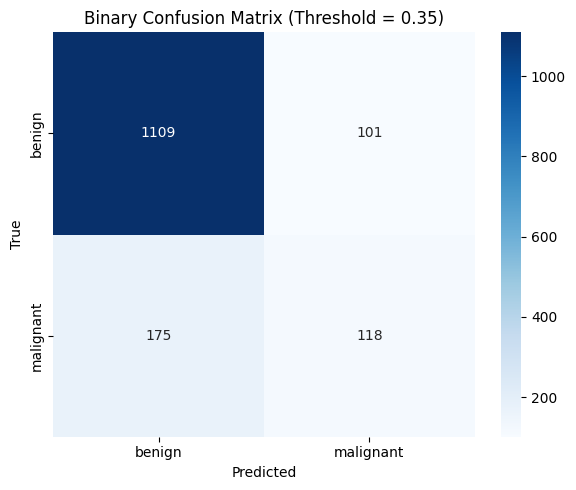

In [49]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

chosen_threshold = 0.35
binary_pred_labels_best = (binary_pred_probs > chosen_threshold).astype(int)

binary_cm = confusion_matrix(binary_true_labels, binary_pred_labels_best)

plt.figure(figsize=(6,5))
sns.heatmap(
    binary_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["benign", "malignant"],
    yticklabels=["benign", "malignant"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Binary Confusion Matrix (Threshold = {chosen_threshold})")
plt.tight_layout()
plt.show()

In [50]:
from tensorflow.keras.models import load_model

binary_checkpoint_path_v2 = "/Users/vihangainduwara/Desktop/MelanoDetect copy/models/ham10000_binary_cnn_v2.keras"
best_binary_model = load_model(binary_checkpoint_path_v2)

print("Best binary model loaded successfully")

Best binary model loaded successfully


In [51]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array, array_to_img

def get_img_array(img_path, size=(224, 224)):
    img = load_img(img_path, target_size=size)
    array = img_to_array(img) / 255.0
    array = np.expand_dims(array, axis=0)
    return array

def build_gradcam_model_from_sequential(base_model, last_conv_layer_name="conv2d_7"):
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = inputs
    last_conv_output = None

    for layer in base_model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            last_conv_output = x

    grad_model = tf.keras.Model(inputs=inputs, outputs=[last_conv_output, x])
    return grad_model

def make_gradcam_heatmap(img_array, grad_model):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap.numpy()

def display_gradcam_overlay(img_path, heatmap, alpha=0.4):
    img = load_img(img_path)
    img = img_to_array(img)

    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps["jet"]
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

    plt.figure(figsize=(6,6))
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [52]:
sample_img_path = "/Users/vihangainduwara/Desktop/MelanoDetect copy/data/ham10000/HAM10000_images_part_1/ISIC_0024306.jpg"

img_array = get_img_array(sample_img_path)
grad_model = build_gradcam_model_from_sequential(best_binary_model, last_conv_layer_name="conv2d_7")
heatmap = make_gradcam_heatmap(img_array, grad_model)

plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.axis("off")
plt.tight_layout()
plt.show()

ValueError: All `outputs` values must be KerasTensors. Received: outputs=[None, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_187>] including invalid value None of type <class 'NoneType'>

In [53]:
for layer in best_binary_model.layers:
    print(layer.name, "-", layer.__class__.__name__)

conv2d - Conv2D
max_pooling2d - MaxPooling2D
conv2d_1 - Conv2D
max_pooling2d_1 - MaxPooling2D
conv2d_2 - Conv2D
max_pooling2d_2 - MaxPooling2D
conv2d_3 - Conv2D
max_pooling2d_3 - MaxPooling2D
flatten - Flatten
dense - Dense
dropout - Dropout
dense_1 - Dense


In [54]:
for layer in reversed(best_binary_model.layers):
    if "conv2d" in layer.name.lower():
        print("Last Conv Layer:", layer.name)
        break

Last Conv Layer: conv2d_3


In [55]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array, array_to_img

def get_img_array(img_path, size=(224, 224)):
    img = load_img(img_path, target_size=size)
    array = img_to_array(img) / 255.0
    array = np.expand_dims(array, axis=0)
    return array

def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in the model.")

def build_gradcam_model_from_sequential(base_model):
    last_conv_layer_name = find_last_conv_layer_name(base_model)
    print("Using last conv layer:", last_conv_layer_name)

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = inputs
    last_conv_output = None

    for layer in base_model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            last_conv_output = x

    grad_model = tf.keras.Model(inputs=inputs, outputs=[last_conv_output, x])
    return grad_model

def make_gradcam_heatmap(img_array, grad_model):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap.numpy()

def display_gradcam_overlay(img_path, heatmap, alpha=0.4):
    img = load_img(img_path)
    img = img_to_array(img)

    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps["jet"]
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

Using last conv layer: conv2d_3


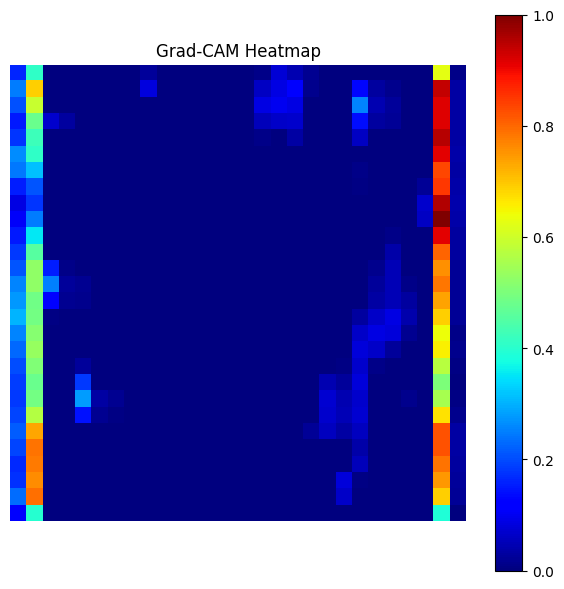

In [56]:
sample_img_path = "/Users/vihangainduwara/Desktop/MelanoDetect copy/data/ham10000/HAM10000_images_part_1/ISIC_0024306.jpg"

img_array = get_img_array(sample_img_path)
grad_model = build_gradcam_model_from_sequential(best_binary_model)
heatmap = make_gradcam_heatmap(img_array, grad_model)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.axis("off")
plt.tight_layout()
plt.show()

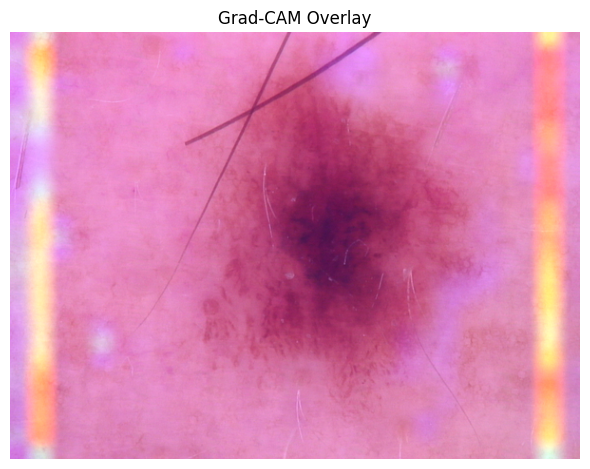

In [57]:
display_gradcam_overlay(sample_img_path, heatmap)

Using last conv layer: conv2d_3


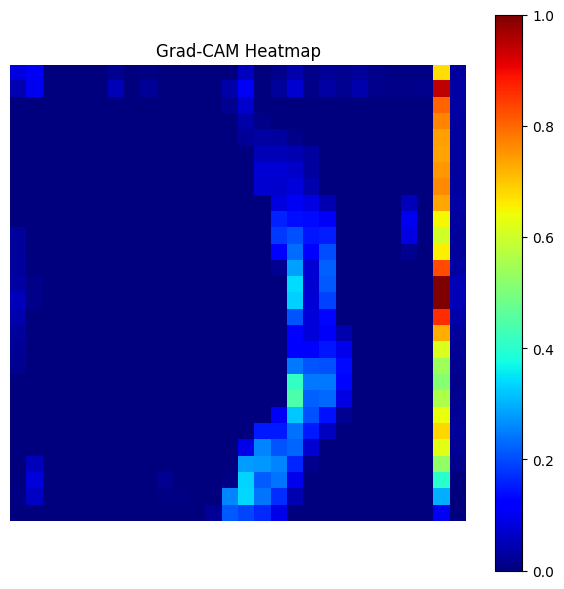

In [59]:
sample_img_path = "/Users/vihangainduwara/Desktop/MelanoDetect copy/data/ham10000/HAM10000_images_part_1/ISIC_0024334.jpg"

img_array = get_img_array(sample_img_path)
grad_model = build_gradcam_model_from_sequential(best_binary_model)
heatmap = make_gradcam_heatmap(img_array, grad_model)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.axis("off")
plt.tight_layout()
plt.show()

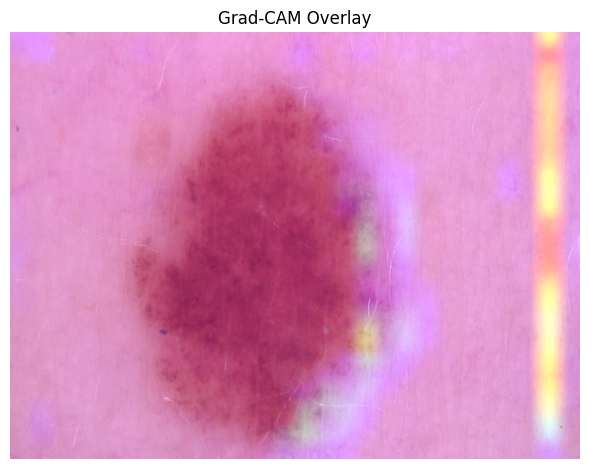

In [60]:
display_gradcam_overlay(sample_img_path, heatmap)

Predicted Label: benign
Confidence: 0.9998100399971008
Threshold Used: 0.35


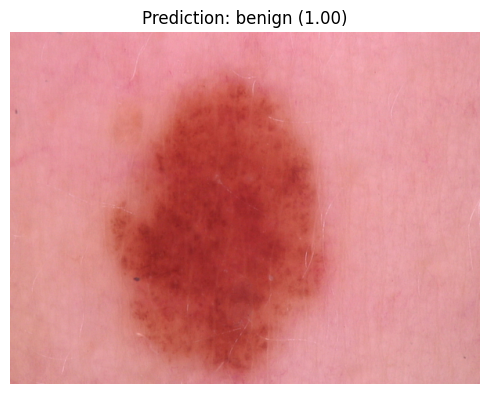

In [61]:
prediction = best_binary_model.predict(img_array, verbose=0)[0][0]

chosen_threshold = 0.35
label = "malignant" if prediction > chosen_threshold else "benign"
confidence = prediction if prediction > chosen_threshold else 1 - prediction

print("Predicted Label:", label)
print("Confidence:", float(confidence))
print("Threshold Used:", chosen_threshold)

plt.figure(figsize=(5,5))
plt.imshow(load_img(sample_img_path))
plt.title(f"Prediction: {label} ({confidence:.2f})")
plt.axis("off")
plt.tight_layout()
plt.show()